In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
r2_score
)
from scipy import stats
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df= pd.read_csv('houses_improved.csv')
df.head()

,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Construction_Materials,Housing_Typology,Land_Value_Grading,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Type_of_Nearest_Road,Proximity_to_Schools_km,Price_ETB
0,3,402,275,18,Concrete,Semi-detached,Low,0.66,0.39,Gravel,1.51,2453165
1,6,111,72,5,Concrete,Semi-detached,High,0.12,1.38,Asphalt,2.04,2006785
2,4,417,306,2,Concrete,Condominium,Medium,5.00,2.21,Gravel,2.71,2164504
3,4,179,72,4,Mud&Wood,Condominium,Low,4.03,1.08,Asphalt,1.30,400087
4,3,315,147,12,Concrete,Semi-detached,Medium,3.95,1.26,Asphalt,2.89,1366641


In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (1000, 12)


In [5]:
print("Statistical Summary")
print("-" * 50)
df.describe()

Statistical Summary
--------------------------------------------------


,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Proximity_to_Schools_km,Price_ETB
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,3.716000,356.639000,204.622000,12.61800,2.510380,1.265490,1.586820,2.111505e+06
std,1.001172,147.084808,93.434861,7.56527,1.421643,0.681525,0.799072,1.375801e+06
min,2.000000,100.000000,44.000000,0.00000,0.100000,0.100000,0.200000,4.000000e+05
25%,3.000000,230.750000,128.750000,6.00000,1.280000,0.687500,0.910000,1.087284e+06
50%,4.000000,365.500000,202.000000,13.00000,2.480000,1.260000,1.590000,1.789488e+06
75%,4.000000,481.000000,269.000000,19.00000,3.802500,1.822500,2.260000,2.822250e+06
max,6.000000,599.000000,438.000000,25.00000,5.000000,2.500000,3.000000,9.779324e+06


In [6]:
print("Missing Values")
print("-" * 50)
print(df.isnull().sum())

Missing Values
--------------------------------------------------
Number_of_Rooms                0
Site_Area_sqm                  0
Built_Area_sqm                 0
Property_Years                 0
Construction_Materials         0
Housing_Typology               0
Land_Value_Grading             0
Proximity_to_CBD_km            0
Proximity_to_Bus_Station_km    0
Type_of_Nearest_Road           0
Proximity_to_Schools_km        0
Price_ETB                      0
dtype: int64


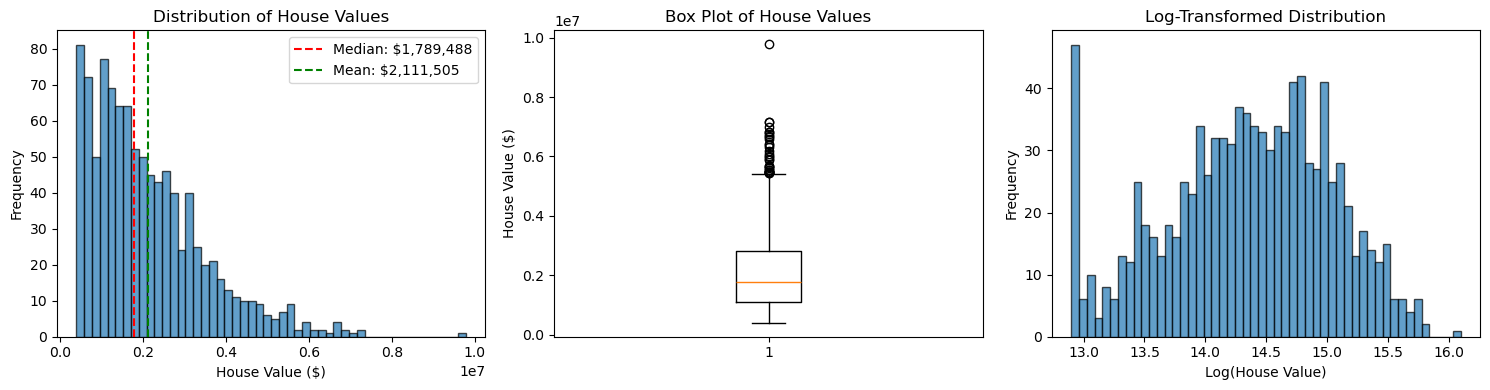

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# --------------------------
# Histogram
# --------------------------
axes[0].hist(
    df["Price_ETB"],
    bins=50,
    edgecolor="black",
    alpha=0.7
)
axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df["Price_ETB"].median(),
    color="red",
    linestyle="--",
    label=f"Median: ${df['Price_ETB'].median():,.0f}"
)
axes[0].axvline(
    df["Price_ETB"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: ${df['Price_ETB'].mean():,.0f}"
)
axes[0].legend()

# --------------------------
# Box Plot
# --------------------------
axes[1].boxplot(df["Price_ETB"])
axes[1].set_title("Box Plot of House Values")
axes[1].set_ylabel("House Value ($)")
# --------------------------
# Log Transformation
# --------------------------
axes[2].hist(
np.log1p(df["Price_ETB"]),
bins=50,
edgecolor="black",
alpha=0.7
)
axes[2].set_title("Log-Transformed Distribution")
axes[2].set_xlabel("Log(House Value)")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [10]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
    df[numeric_columns]
    .corr()["Price_ETB"]
    .sort_values(ascending=False)
)
print("Top Correlations with House Price")
print(correlations)

Top Correlations with House Price
Price_ETB                      1.000000
Built_Area_sqm                 0.623637
Site_Area_sqm                  0.563448
Number_of_Rooms               -0.014894
Proximity_to_Bus_Station_km   -0.069370
Proximity_to_Schools_km       -0.084817
Property_Years                -0.270473
Proximity_to_CBD_km           -0.301698
Name: Price_ETB, dtype: float64


In [ ]:
# Correlation
# Meaning
# +1 Strong positive relationship
# 0 No relationship
# -1 Strong negative relationship

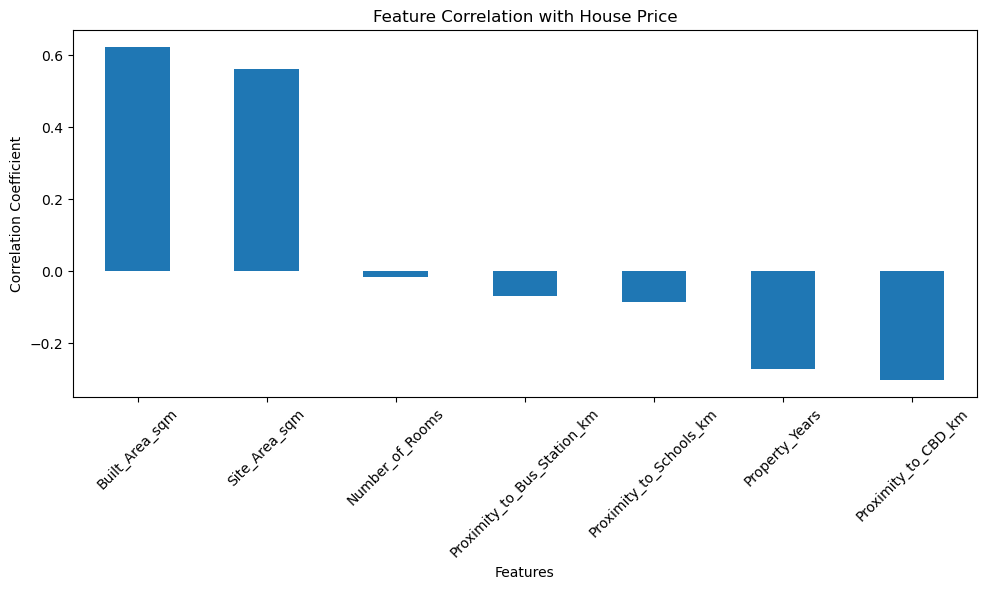

In [11]:
plt.figure(figsize=(10, 6))
correlations.drop("Price_ETB").plot(kind="bar")
plt.title("Feature Correlation with House Price")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

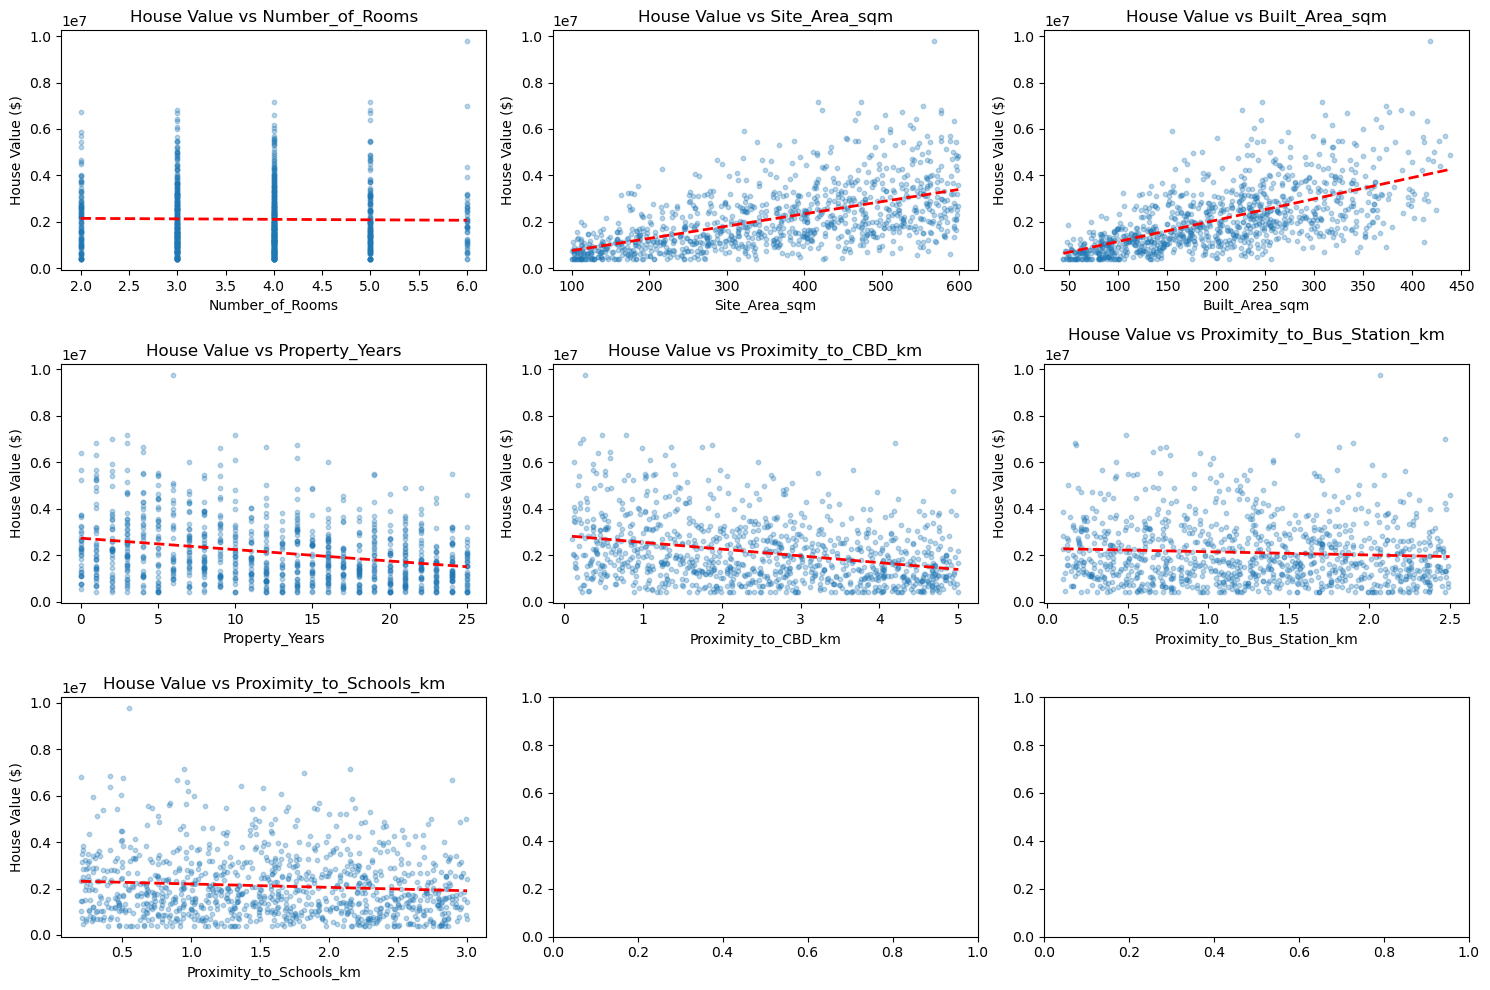

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features = [
    "Number_of_Rooms",
    "Site_Area_sqm",
    "Built_Area_sqm",
    "Property_Years",
    "Proximity_to_CBD_km",
    "Proximity_to_Bus_Station_km",
    "Proximity_to_Schools_km"
    
]
for index, feature in enumerate(features):
    row = index // 3
    column = index % 3
    axes[row, column].scatter(
        df[feature],
        df["Price_ETB"],
        alpha=0.3,
        s=10
    )
    axes[row, column].set_title(f"House Value vs {feature}")
    axes[row, column].set_xlabel(feature)
    axes[row, column].set_ylabel("House Value ($)")
    # Add linear trend line
    z = np.polyfit(df[feature], df["Price_ETB"], 1)
    p = np.poly1d(z)
    axes[row, column].plot(
        df[feature].sort_values(),
        p(df[feature].sort_values()),
"r--",
linewidth=2
)
plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['Number_of_Rooms', 'Site_Area_sqm', 'Built_Area_sqm', 'Property_Years',
       'Construction_Materials', 'Housing_Typology', 'Land_Value_Grading',
       'Proximity_to_CBD_km', 'Proximity_to_Bus_Station_km',
       'Type_of_Nearest_Road', 'Proximity_to_Schools_km', 'Price_ETB'],
      dtype='object')

In [17]:
#Univariant Linear Regression

In [18]:
#Selecting Features
#Independent variable (X)
X = df[['Built_Area_sqm']]

#Target variable
y = df [['Price_ETB']]

In [20]:
#Splitting Dataset
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
#Training Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
#view the equation
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept : {intercept}")
print(f"Coefficient : {coefficient}")

Intercept : [185101.81754326]
Coefficient : [9373.66793167]


In [32]:
df.shape

(1000, 12)

In [37]:
#Making predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [44]:
#Evaluate the model
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score (y_test, test_predictions)

print(f"train_rmse: {train_rmse}")
print(f"test_rmse: {test_rmse}")

print(f"train_r2: {train_r2}")
print(f"test_r2: {test_r2}")

train_rmse: 1090905.8754342098
test_rmse: 1009536.2787062986
train_r2: 0.38942416023512016
test_r2: 0.3847461988900538


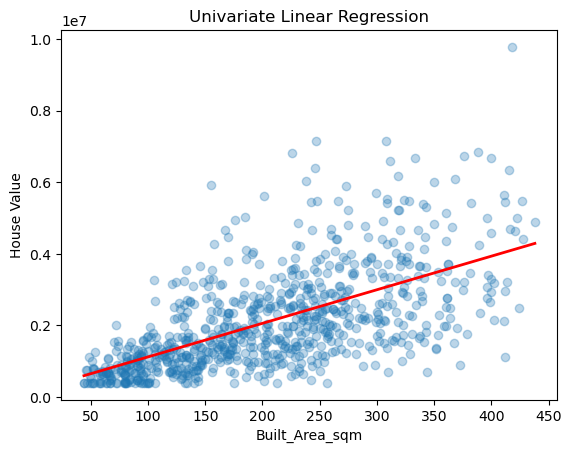

In [46]:
plt.scatter(X_train, y_train, alpha=0.3)
X_sorted = X_train.sort_values("Built_Area_sqm")
y_sorted = model.predict(X_sorted)
plt.plot(
X_sorted,
y_sorted,
color="red",
linewidth=2
)
plt.xlabel("Built_Area_sqm")
plt.ylabel("House Value")
plt.title("Univariate Linear Regression")
plt.show()

In [47]:
# Metric Value
# RMSE = 1,009,536
# R² = 0.384

In [48]:
#Multivariate Linear Regression

In [52]:
#Encoding 
encoder = LabelEncoder()
df["Construction_Materials_encoded"] = encoder.fit_transform(df["Construction_Materials"])
df["Housing_Typology_encoded"] = encoder.fit_transform(df["Housing_Typology"])
df["Land_Value_Grading_encoded"] = encoder.fit_transform(df["Land_Value_Grading"])
df["Type_of_Nearest_Road_encoded"] = encoder.fit_transform(df["Type_of_Nearest_Road"])
df

,Number_of_Rooms,Site_Area_sqm,Built_Area_sqm,Property_Years,Construction_Materials,Housing_Typology,Land_Value_Grading,Proximity_to_CBD_km,Proximity_to_Bus_Station_km,Type_of_Nearest_Road,Proximity_to_Schools_km,Price_ETB,Construction_Materials_encoded,Housing_Typology_encoded,Land_Value_Grading_encoded,Type_of_Nearest_Road_encoded
0,3,402,275,18,Concrete,Semi-detached,Low,0.66,0.39,Gravel,1.51,2453165,0,2,1,1
1,6,111,72,5,Concrete,Semi-detached,High,0.12,1.38,Asphalt,2.04,2006785,0,2,0,0
2,4,417,306,2,Concrete,Condominium,Medium,5.00,2.21,Gravel,2.71,2164504,0,0,2,1
3,4,179,72,4,Mud&Wood,Condominium,Low,4.03,1.08,Asphalt,1.30,400087,1,0,1,0
4,3,315,147,12,Concrete,Semi-detached,Medium,3.95,1.26,Asphalt,2.89,1366641,0,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,327,143,0,Mud&Wood,Semi-detached,Medium,4.04,1.85,Gravel,0.49,1097298,1,2,2,1
996,5,370,258,24,Concrete,Semi-detached,Low,0.42,0.68,Gravel,1.92,2040138,0,2,1,1
997,3,142,78,13,Concrete,Condominium,Medium,3.49,0.51,Gravel,0.46,702584,0,0,2,1
998,6,531,369,4,Mud&Wood,Detached,Medium,2.90,1.37,Gravel,2.31,3151172,1,1,2,1


In [54]:
#select features
features = [
    'Number_of_Rooms',
    'Site_Area_sqm', 
    'Built_Area_sqm', 
    'Property_Years',
    'Construction_Materials_encoded', 
    'Housing_Typology_encoded',
    'Land_Value_Grading_encoded',
    'Proximity_to_CBD_km',
    'Proximity_to_Bus_Station_km',
    'Type_of_Nearest_Road_encoded',
    'Proximity_to_Schools_km' 
]
X = df[features]
y = df["Price_ETB"]

In [55]:
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state = 42
)

In [56]:
#Standardizing Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
#Train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
#Displaying Feature Importance
coefficients = pd.DataFrame({
"Feature": features,
"Coefficient": model.coef_
})
coefficients["Absolute"] = coefficients["Coefficient"].abs()
coefficients.sort_values(
"Absolute",
ascending=False,
inplace=True
)
print(coefficients)

                           Feature    Coefficient       Absolute
2                   Built_Area_sqm  864605.157107  864605.157107
3                   Property_Years -465878.678569  465878.678569
7              Proximity_to_CBD_km -462553.962258  462553.962258
4   Construction_Materials_encoded -437813.193443  437813.193443
9     Type_of_Nearest_Road_encoded -192132.052343  192132.052343
8      Proximity_to_Bus_Station_km -143131.259525  143131.259525
10         Proximity_to_Schools_km -129704.011029  129704.011029
6       Land_Value_Grading_encoded -126386.528275  126386.528275
5         Housing_Typology_encoded   58500.257869   58500.257869
1                    Site_Area_sqm   48042.954419   48042.954419
0                  Number_of_Rooms    1082.663223    1082.663223


In [59]:
#Making Pridictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [61]:
train_rmse = np.sqrt(
mean_squared_error(y_train, train_predictions)
)
test_rmse = np.sqrt(
mean_squared_error(y_test, test_predictions)
)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(f"train_rmse: {train_rmse}")
print(f"test_rmse: {test_rmse}")

print(f"train_r2: {train_r2}")
print(f"test_r2: {test_r2}")

train_rmse: 731842.0666483057
test_rmse: 724054.4518748955
train_r2: 0.7252107159676593
test_r2: 0.6835151676889175


In [ ]:
# Metrics
# Univariant
# train_rmse: 1,090,905
# test_rmse: 1,009,536
# train_r2: 0.389 or 38%
# test_r2: 0.384 or 38%

# Multivariant
# train_rmse: 731,842
# test_rmse: 724,054
# train_r2: 0.725 or 72%
# test_r2: 0.683 or 68%

# The Multivariate Linear Regression model performs better because:
# It has a lower RMSE, meaning smaller prediction errors.
# It has a higher R² score, explaining more variation in house prices.
# It uses information from multiple features instead of relying only on median income.

#Final Conclusion
# Univariate 
# R2=0.384
# RMSE=1,009,536
# Good for learning linear regression concepts.
    
# Multivariate
# R2=0.683
# RMSE=724,054
# Recommended for making more accurate predictions.